# Rohde & Schwarz RTP Export Examples

**Scott Prahl**

**Mar 2026**

In [1]:
%config InlineBackend.figure_format = 'retina'

import io

import numpy as np
import matplotlib.pyplot as plt
import requests
from RigolWFM import Wfm

repo = "https://raw.githubusercontent.com/scottprahl/RigolWFM/main/tests/files/"


def sample_url(relative_path: str) -> str:
    return repo + relative_path


def _time_scale(times):
    span = float(abs(times[-1] - times[0])) if len(times) > 1 else 1.0
    if span >= 1e-3:
        return 1e3, "ms"
    if span >= 1e-6:
        return 1e6, "us"
    if span >= 1e-9:
        return 1e9, "ns"
    return 1e12, "ps"


def _volt_scale(values):
    peak = max(float(np.max(np.abs(v))) for v in values) if values else 1.0
    if peak >= 1.0:
        return 1.0, "V"
    if peak >= 1e-3:
        return 1e3, "mV"
    if peak >= 1e-6:
        return 1e6, "uV"
    return 1e9, "nV"


def plot_analog_channels(w, title=None, max_points=5000):
    active = [ch for ch in w.channels if ch.times is not None and ch.volts is not None]
    if not active:
        print("No analog channels are enabled in this capture.")
        return

    colors = ["green", "red", "blue", "orange"]
    t_scale, t_unit = _time_scale(active[0].times)
    v_scale, v_unit = _volt_scale([ch.volts for ch in active])

    fig, axes = plt.subplots(len(active), 1, sharex=True, figsize=(10, 2.5 * len(active)))
    if len(active) == 1:
        axes = [axes]

    for ax, ch, color in zip(axes, active, colors):
        stride = max(len(ch.times) // max_points, 1)
        ax.plot(ch.times[::stride] * t_scale, ch.volts[::stride] * v_scale, color=color)
        ax.set_ylabel(v_unit)
        ax.set_title(f"CH{ch.channel_number}  {ch.points} points")
        ax.grid(True)

    axes[-1].set_xlabel(f"Time ({t_unit})")
    if title:
        fig.suptitle(title)
    plt.tight_layout()
    plt.show()


def plot_logic_window(w, names=None, start=0, stop=4000, title=None):
    if not w.logic_channels:
        print("No logic channels are enabled in this capture.")
        return

    if names is None:
        names = list(w.logic_channels)

    if w.logic_times is None:
        times = np.arange(len(next(iter(w.logic_channels.values()))), dtype=np.float64)
    else:
        times = w.logic_times

    stop = min(stop, len(times))
    t_scale, t_unit = _time_scale(times[start:stop])

    fig, axes = plt.subplots(len(names), 1, sharex=True, figsize=(10, 1.6 * len(names)))
    if len(names) == 1:
        axes = [axes]

    colors = ["green", "red", "blue", "orange", "purple", "brown"]
    for ax, name, color in zip(axes, names, colors):
        trace = w.logic_channels[name]
        ax.step(times[start:stop] * t_scale, trace[start:stop], where="post", color=color)
        ax.set_ylim(-0.2, 1.2)
        ax.set_yticks([0, 1])
        ax.set_ylabel(name)
        ax.grid(True)

    axes[-1].set_xlabel(f"Time ({t_unit})")
    if title:
        fig.suptitle(title)
    plt.tight_layout()
    plt.show()


def load_vendor_csv(relative_path: str):
    response = requests.get(sample_url(relative_path), timeout=30)
    response.raise_for_status()
    data = np.loadtxt(io.StringIO(response.text), delimiter=",", dtype=np.float64)
    if data.ndim == 1:
        data = data[:, np.newaxis]
    return data

## `rs_rtp_01.bin` - Single-channel analog export

In [2]:
filename = "rs/rs_rtp_01.bin"
w = Wfm.from_url(sample_url(filename), "RohdeSchwarz")
print(w.describe())

    General:
        File Model   = Rohde & Schwarz
        User Model   = RohdeSchwarz
        Parser Model = rohde_schwarz_bin
        Firmware     = unknown
        Filename     = rs_rtp_01.bin
        Channels     = [1]

    Trigger:
        Derived Level (CH1) = 1.03  V

     Channel 1:
         Coupling =  unknown
            Scale =   400.00 mV/div
           Offset =     0.00  V
            Probe =       1X
         Inverted =    False

        Time Base =  500.000 µs/div
           Offset =    0.000  s
            Delta =    1.250 µs/point
           Points =     4000

         Count    = [        1,        2,        3  ...      3999,     4000]
           Raw    = [      247,      240,      236  ...        18,       11]
           Times  = [-2.500 ms,-2.499 ms,-2.498 ms  ...  2.498 ms, 2.499 ms]
           Volts  = [-31.62 mV,  0.00  V, 15.81 mV  ... 996.05 mV,  1.03  V]




downloading 'https://raw.githubusercontent.com/scottprahl/RigolWFM/main/tests/files/rs/rs_rtp_01.bin'
downloading 'https://raw.githubusercontent.com/scottprahl/RigolWFM/main/tests/files/rs/rs_rtp_01.Wfm.bin'


### Plot the decoded waveform

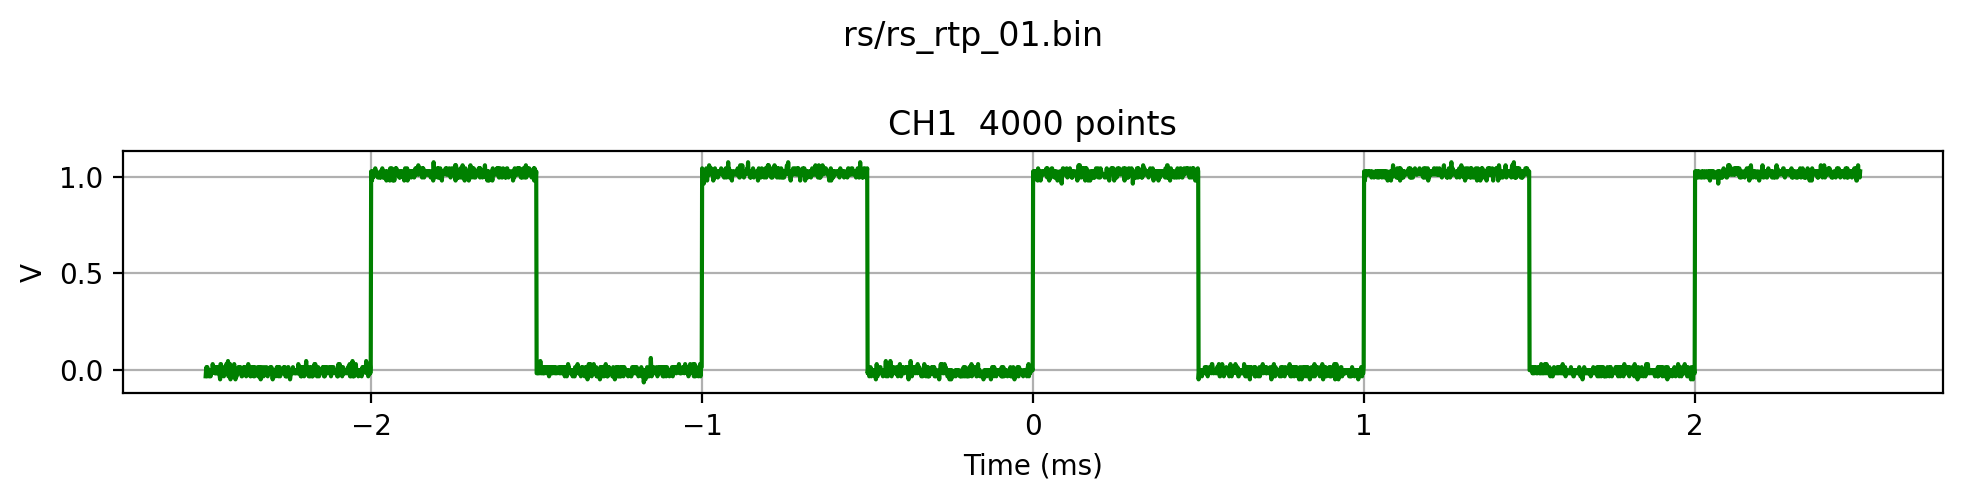

In [3]:
plot_analog_channels(w, title=filename)

## `rs_rtp_02.bin` - Two-channel analog export

In [4]:
filename = "rs/rs_rtp_02.bin"
w = Wfm.from_url(sample_url(filename), "RohdeSchwarz")
print(w.describe())

downloading 'https://raw.githubusercontent.com/scottprahl/RigolWFM/main/tests/files/rs/rs_rtp_02.bin'
downloading 'https://raw.githubusercontent.com/scottprahl/RigolWFM/main/tests/files/rs/rs_rtp_02.Wfm.bin'


    General:
        File Model   = Rohde & Schwarz
        User Model   = RohdeSchwarz
        Parser Model = rohde_schwarz_bin
        Firmware     = unknown
        Filename     = rs_rtp_02.bin
        Channels     = [1, 2]

    Trigger:
        Derived Level (CH1) = 1.03  V
        Derived Level (CH2) = 221.34 mV

     Channel 1:
         Coupling =  unknown
            Scale =   400.00 mV/div
           Offset =     0.00  V
            Probe =       1X
         Inverted =    False

        Time Base =  500.000 µs/div
           Offset =    0.000  s
            Delta =    1.250 µs/point
           Points =     4000

         Count    = [        1,        2,        3  ...      3999,     4000]
           Raw    = [      247,      240,      236  ...        18,       11]
           Times  = [-2.500 ms,-2.499 ms,-2.498 ms  ...  2.498 ms, 2.499 ms]
           Volts  = [-31.62 mV,  0.00  V, 15.81 mV  ... 996.05 mV,  1.03  V]

     Channel 2:
         Coupling =  unknown
            Scale 

### Plot both channels

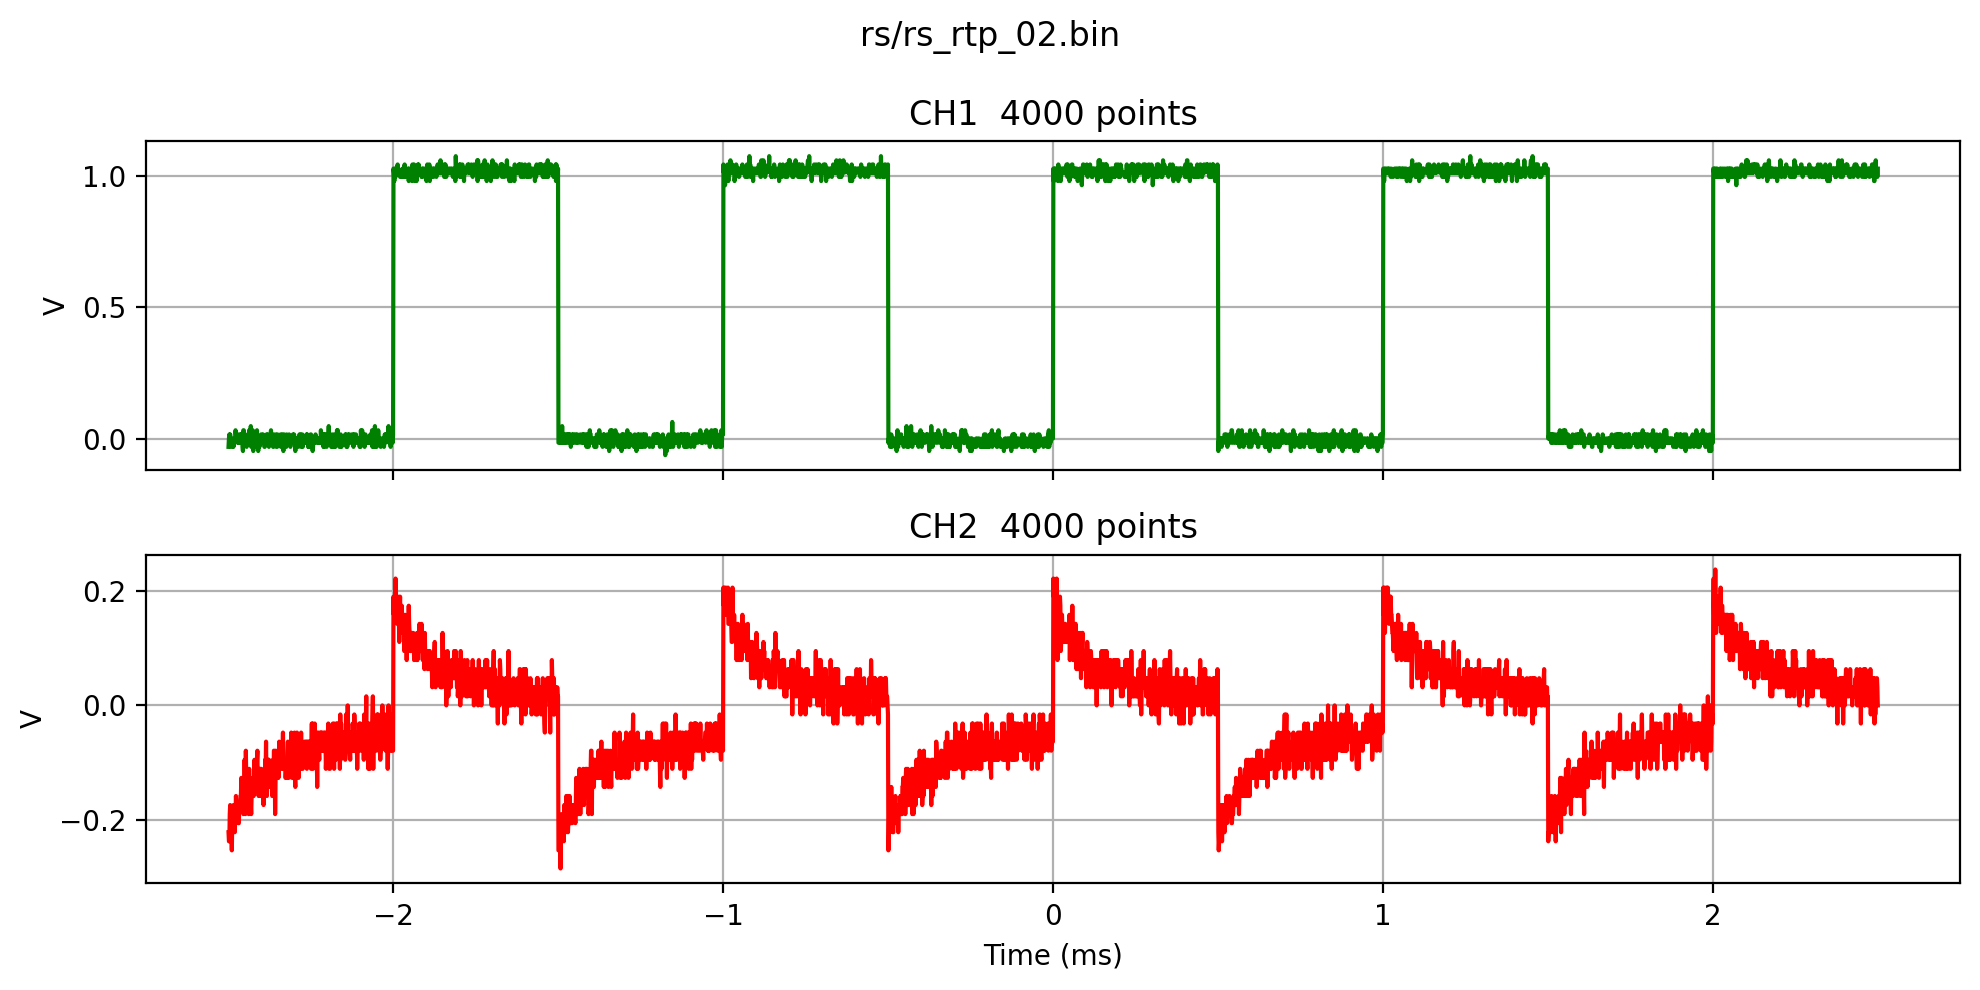

In [5]:
plot_analog_channels(w, title=filename)

## `rs_rtp_04.bin` - Compare RigolWFM output to the vendor CSV

In [6]:
filename = "rs/rs_rtp_04.bin"
w = Wfm.from_url(sample_url(filename), "RohdeSchwarz")
csv = load_vendor_csv("rs/rs_rtp_04.Wfm.csv")
times = w.channels[0].times
volts = w.channels[0].volts
vendor_times = csv[:, 0]
vendor_volts = csv[:, 1]
print(f"Max abs voltage difference: {np.max(np.abs(volts - vendor_volts)):.6e} V")
print(f"Max abs time difference:    {np.max(np.abs(times - vendor_times)):.6e} s")

downloading 'https://raw.githubusercontent.com/scottprahl/RigolWFM/main/tests/files/rs/rs_rtp_04.bin'
downloading 'https://raw.githubusercontent.com/scottprahl/RigolWFM/main/tests/files/rs/rs_rtp_04.Wfm.bin'


Max abs voltage difference: 4.964130e-08 V
Max abs time difference:    1.895898e-20 s


### Overlay the first 500 samples

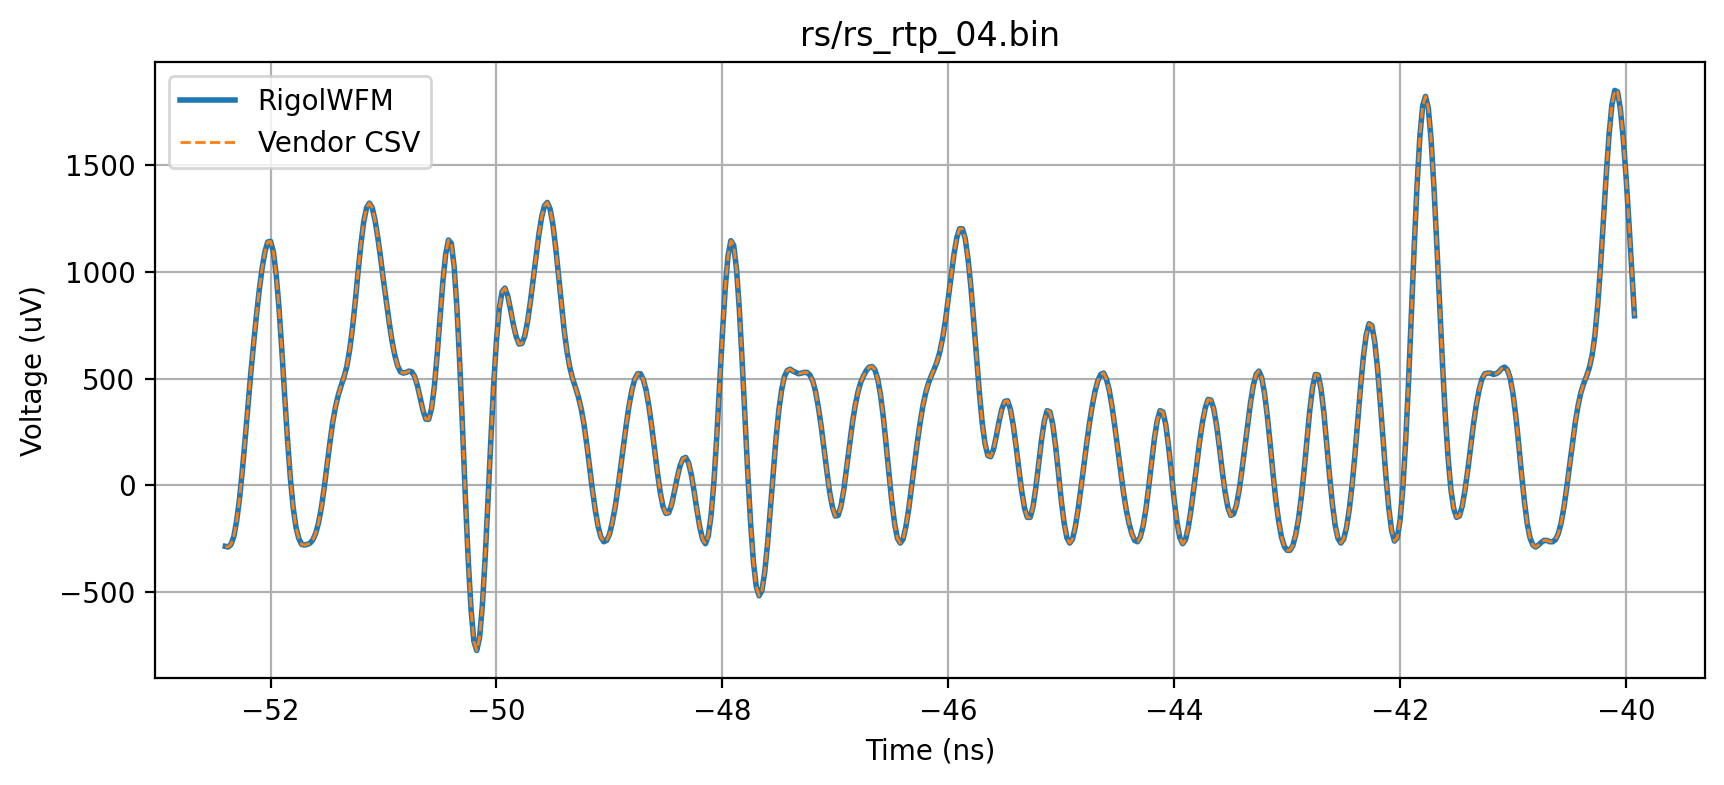

In [7]:
plt.figure(figsize=(10, 4))
plt.plot(times[:500] * 1e9, volts[:500] * 1e6, label="RigolWFM", linewidth=2)
plt.plot(vendor_times[:500] * 1e9, vendor_volts[:500] * 1e6, "--", label="Vendor CSV", linewidth=1)
plt.xlabel("Time (ns)")
plt.ylabel("Voltage (uV)")
plt.title(filename)
plt.grid(True)
plt.legend()
plt.show()